In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.linalg import hessenberg

# Projeto 3 de Algebra Linear Numérica

### 1. Redução à Forma de Hessenberg

**a) _Cálculo dos refletores_. Escreva uma função `to_hessemberg(A)` que calcula a forma de Hessemberg de uma matriz A usando refletores de Householder. A função deve retornar uma lista de refletores $v_i$, a matriz $H$ tal que $A = QHQ^∗$, e $Q$, que é a matriz ortogonal dada pelo produto dos refletores**

In [32]:
def sign(x):
    return -1 if x < 0 else 1

In [51]:
def to_hessenberg(A: np.ndarray) -> tuple[list[np.ndarray], np.ndarray, np.ndarray]:
    """Função que recebe uma matriz A e calcula sua forma de Hessenberg.

    Args:
        A (np.ndarray): Matriz que será calculada

    Returns:
        tuple[list[np.ndarray], np.ndarray, np.ndarray]: Lista contendo os vetores de reflexão v_i, a matriz de
        Hessenberg e a matriz ortogonal Q
    """
    if A.shape[0] != A.shape[1]:
        raise ValueError("Você precisa passar uma matriz quadrada")

    M = A.copy()

    reflectors = []
    m = M.shape[0]
    Q = np.identity(m)

    for k in range(m-2):
        x = M[k+1:m, k].reshape(-1, 1)
        v_k = sign(x[0]) * np.linalg.norm(x) * np.eye(x.shape[0], 1) + x
        v_k = v_k / np.linalg.norm(v_k)
        M[k+1:m, k:m] -= 2 * v_k @ (v_k.T @ M[k+1:m, k:m])
        M[0:m, k+1:m] -= 2 * (M[0:m, k+1:m] @ v_k) @ v_k.T

        Q[k+1:m, k+1:m] @= v_k @ v_k.T

        reflectors.append(v_k)    

    Q = np.eye(m)
    for k, v_k in enumerate(reflectors):
        H_k = np.eye(m)
        H_k[k + 1:m, k + 1:m] -= 2 * (v_k @ v_k.T)
        Q = Q @ H_k

    return reflectors, M, Q

**b\) Verifique que sua função de fato está correta, calculando $\|A −QHQ^∗\|$ e $\|Q^∗Q −I\|$ para diversas matrizes A: use simétricas e não simétricas, e de diferentes tamanhos**

In [60]:
normal_matrices = [np.random.random_sample((m, m)) for m in range(2, 100)]
matrices_to_symetrize = [np.random.random_sample((m, m)) for m in range(2, 100)]
symetric_matrices = []
for matrix in matrices_to_symetrize:
    m = (matrix + matrix.T)/2
    symetric_matrices.append(m)

In [94]:
normal_hessenbergs = [to_hessenberg(m) for m in normal_matrices]
symetric_hessenbergs = [to_hessenberg(m) for m in symetric_matrices]

In [96]:
norms_difference_normals = []
norms_difference_symetrics = []

identities_difference_normals = []
identities_difference_symetrics = []

for i in range(len(normal_hessenbergs)):
    # Adicionando das matrizes comuns
    norm_normal = np.linalg.norm(
        normal_matrices[i] - normal_hessenbergs[i][2] @ normal_hessenbergs[i][1] @ normal_hessenbergs[i][2].T
    )
    norms_difference_normals.append(norm_normal)

    # Adicionando das matrizes simétricas
    norm_symetric = np.linalg.norm(
        symetric_matrices[i] - symetric_hessenbergs[i][2] @ symetric_hessenbergs[i][1] @ symetric_hessenbergs[i][2].T
    )
    norms_difference_symetrics.append(norm_symetric)


    # Adicionando das matrizes comuns
    identity_difference_normal = np.linalg.norm(
        np.identity(i+2) - normal_hessenbergs[i][2].T @ normal_hessenbergs[i][2]
    )
    identities_difference_normals.append(identity_difference_normal)

    # Adicionando das matrizes simétricas
    identity_difference_symetric = np.linalg.norm(
        np.identity(i+2) - symetric_hessenbergs[i][2].T @ symetric_hessenbergs[i][2]
    )
    identities_difference_symetrics.append(identity_difference_symetric)

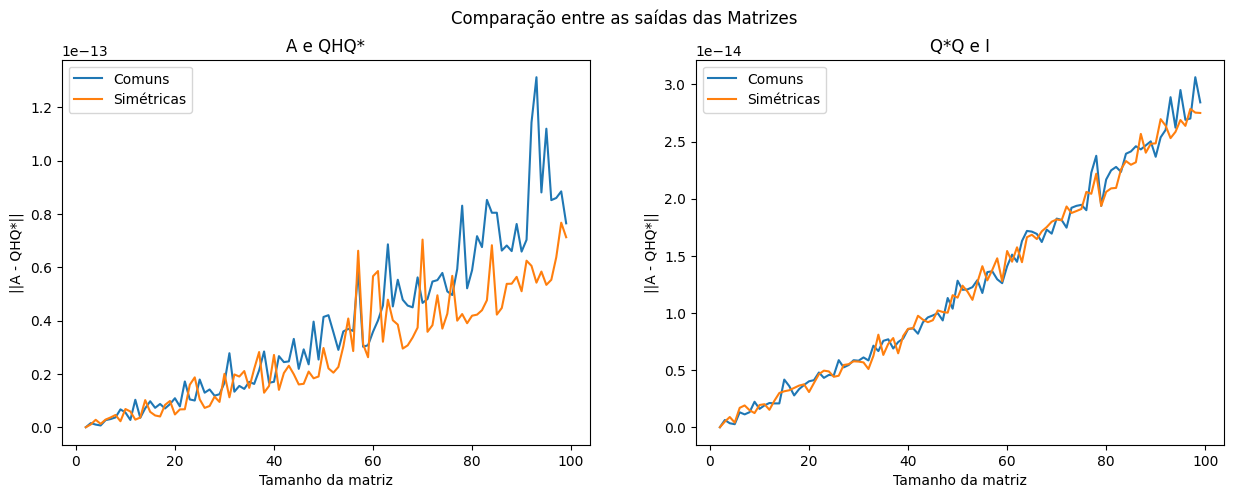

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle("Comparação entre as saídas das Matrizes")

axes[0].set_title("A e QHQ*")
axes[1].set_title("Q*Q e I")

axes[0].plot(range(2, 100), norms_difference_normals, label="Comuns")
axes[0].plot(range(2, 100), norms_difference_symetrics, label="Simétricas")

axes[1].plot(range(2, 100), identities_difference_normals, label="Comuns")
axes[1].plot(range(2, 100), identities_difference_symetrics, label="Simétricas")

axes[0].set_xlabel("Tamanho da matriz")
axes[0].set_ylabel("||A - QHQ*||")
axes[1].set_xlabel("Tamanho da matriz")
axes[1].set_ylabel("||A - QHQ*||")

axes[0].legend()
axes[1].legend()
plt.show()